<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Учебный кейс: проверка статистической гипотезы
*Шаблон для выполнения задания*

**Датасет:** [Coffee Quality Database (CQI)](https://www.kaggle.com/datasets/volpatto/coffee-quality-database-from-cqi)

## 📊 Описание датасета

В данном задании используется датасет с результатами каппинга (дегустационной оценки) кофе сорта Arabica, собранный Coffee Quality Institute (CQI). Каждая строка — один образец кофе, оценённый сертифицированным дегустатором (Q-grader).

**Бизнес-контекст:** вы — аналитик в компании-импортёре specialty-кофе. Компания закупает зерно напрямую у фермеров из разных стран. Перед заключением новых контрактов руководство хочет проверить качество закупаемого кофе с помощью статистических методов.

**Что такое specialty-кофе?** По стандарту Specialty Coffee Association (SCA), specialty-кофе — это кофе, получивший при слепой дегустации **80 баллов и выше** из 100 возможных.

**Ключевые признаки:**
- `Total.Cup.Points` — итоговый балл каппинга (0–100)
- `Country.of.Origin` — страна происхождения
- `Variety` — сорт кофе
- `Processing.Method` — метод обработки (Washed / Natural / Pulped natural / etc.)
- `altitude_mean_meters` — средняя высота выращивания (метры)
- `Aroma` — балл за аромат (0–10)
- `Flavor` — балл за вкус (0–10)
- `Aftertaste` — балл за послевкусие (0–10)
- `Acidity` — балл за кислотность (0–10)
- `Body` — балл за тело (0–10)


## 1. Импорт библиотек и загрузка данных



In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

path = kagglehub.dataset_download("volpatto/coffee-quality-database-from-cqi")
df = pd.read_csv(f"{path}/arabica_data_cleaned.csv")
df.head()

100%|██████████| 254k/254k [00:00<00:00, 38.7MB/s]

Extracting files...


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


## 2. Первичный анализ данных

Ознакомьтесь с данными:
- Сколько строк и столбцов?
- Какие типы данных у каждого столбца?
- Выведите описательные статистики для столбца `Total.Cup.Points`
- Постройте гистограмму распределения `Total.Cup.Points` с линией среднего значения
- Есть ли строки с `Total.Cup.Points == 0` или аномально низкими значениями? Есть ли какие-то еще проблемы в данных? Если да — примите решения по обработке.

In [ ]:
# Ячейка 2.1: структура и типы данных
print("Типы данных по столбцам:")
print(df.dtypes)

print("\nПервые 5 строк:")
df.head()

Типы данных по столбцам:
Unnamed: 0                 int64
Species                   object
Owner                     object
Country.of.Origin         object
Farm.Name                 object
Lot.Number                object
Mill                      object
ICO.Number                object
Company                   object
Altitude                  object
Region                    object
Producer                  object
Number.of.Bags             int64
Bag.Weight                object
In.Country.Partner        object
Harvest.Year              object
Grading.Date              object
Owner.1                   object
Variety                   object
Processing.Method         object
Aroma                    float64
Flavor                   float64
Aftertaste               float64
Acidity                  float64
Body                     float64
Balance                  float64
Uniformity               float64
Clean.Cup                float64
Sweetness                float64
Cupper.Points     

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [ ]:
# Ячейка 2.2: описательные статистики для Total.Cup.Points
print(df['Total.Cup.Points'].describe())

count    1311.000000
mean       82.115927
std         3.515761
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64


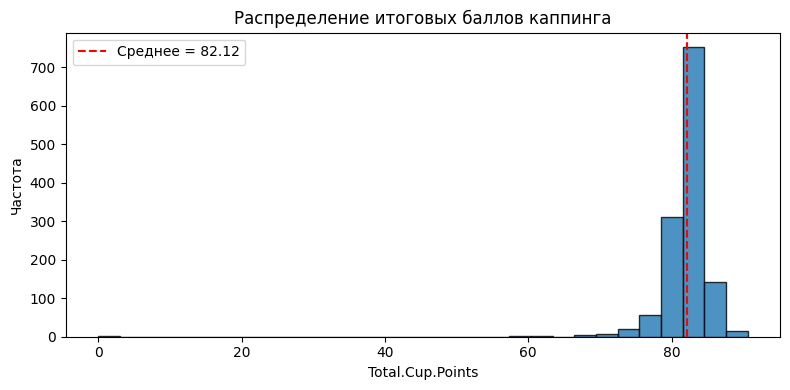

In [ ]:
# Ячейка 2.3: гистограмма Total.Cup.Points с линией среднего
x = df['Total.Cup.Points'].dropna()

plt.figure(figsize=(8, 4))
plt.hist(x, bins=30, edgecolor='black', alpha=0.8)
plt.axvline(x.mean(), color='red', linestyle='--', label=f'Среднее = {x.mean():.2f}')
plt.xlabel('Total.Cup.Points')
plt.ylabel('Частота')
plt.title('Распределение итоговых баллов каппинга')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 2.4: проверка на нули и аномально низкие значения
print("Строк с Total.Cup.Points == 0:", (df['Total.Cup.Points'] == 0).sum())
print("Строк с Total.Cup.Points < 60:", (df['Total.Cup.Points'] < 60).sum())
print("Пропусков в Total.Cup.Points:", df['Total.Cup.Points'].isna().sum())

# Посмотрим на потенциально проблемные строки
problem = df[(df['Total.Cup.Points'] == 0) | (df['Total.Cup.Points'] < 60)]
problem[['Country.of.Origin', 'Variety', 'Processing.Method', 'Total.Cup.Points']]

Строк с Total.Cup.Points == 0: 1
Строк с Total.Cup.Points < 60: 2
Пропусков в Total.Cup.Points: 0


,Country.of.Origin,Variety,Processing.Method,Total.Cup.Points
1309,Guatemala,Catuai,Washed / Wet,59.83
1310,Honduras,Caturra,NaN,0.00


**Ваши наблюдения по первичному осмотру:**

В датасете 1311 строка и 44 столбца.

Большинство признаков числовые (баллы каппинга) и категориальные (страна, сорт, метод обработки).

Распределение Total.Cup.Points сосредоточено около 82 баллов, есть 1 строка с 0 и несколько с очень низкими значениями.

Строки с Total.Cup.Points == 0 логично исключить из анализа как явно ошибочные.

Рекомендации:

Для основного анализа использовать выборку без нулевых значений Total.Cup.Points.

При необходимости отдельно изучить строки с очень низкими баллами (< 60) на предмет ошибок ввода.

## 3. Доверительный интервал для среднего балла

Постройте 95% доверительный интервал для среднего значения `Total.Cup.Points`.

**Шаги:**
1. Рассчитайте выборочное среднее и стандартное отклонение (`ddof=1`)
2. Рассчитайте стандартную ошибку среднего
3. Найдите критическое значение t-распределения через `stats.t.ppf()`
4. Вычислите погрешность и границы интервала
5. Проверьте результат через `stats.t.interval()`

**Интерпретация:** попадает ли порог specialty-кофе (80 баллов) в доверительный интервал? Что это означает?

In [ ]:
# Ячейка 3: доверительный интервал для среднего Total.Cup.Points

# Очистка от нулей и пропусков
x = df['Total.Cup.Points'].dropna()
x = x[x > 0]

n = len(x)
mean = x.mean()
sd = x.std(ddof=1)
se = sd / np.sqrt(n)

# Критическое значение t
tcrit = stats.t.ppf(0.975, df=n-1)

# Погрешность и границы
moe = tcrit * se
ci_low = mean - moe
ci_high = mean + moe

print(f"n = {n}")
print(f"Среднее = {mean:.4f}")
print(f"Стандартное отклонение = {sd:.4f}")
print(f"Стандартная ошибка = {se:.4f}")
print(f"t_crit = {tcrit:.4f}")
print(f"Погрешность = {moe:.4f}")
print(f"95% ДИ: [{ci_low:.4f}, {ci_high:.4f}]")

# Проверка через stats.t.interval
ci_check = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
print("Проверка через t.interval:", ci_check)

n = 1310
Среднее = 82.1786
Стандартное отклонение = 2.6860
Стандартная ошибка = 0.0742
t_crit = 1.9618
Погрешность = 0.1456
95% ДИ: [82.0330, 82.3242]
Проверка через t.interval: (np.float64(82.03302239451656), np.float64(82.32419897952923))


**Ваши выводы по доверительному интервалу:**

**Интерпретация:**
95%-й доверительный интервал для среднего балла: примерно [82.03; 82.32].
Порог specialty-кофе (80 баллов) не попадает в этот интервал.

**Выводы:**
С вероятностью 95% истинное среднее значение Total.Cup.Points в генеральной совокупности выше 80.
Это говорит о том, что в среднем закупаемый кофе соответствует критерию specialty.

**Рекомендации:**
Использовать этот результат как базовый ориентир при оценке новых поставщиков.
При появлении новых данных пересчитывать ДИ и отслеживать, не смещается ли среднее вниз.

## 4. Одновыборочный t-тест: соответствует ли стандарту?

Проверьте гипотезу о том, что средний балл каппинга равен 80 (стандарт specialty).

- Сформулируйте H₀ и H₁
- Проведите одновыборочный t-тест через `stats.ttest_1samp()` с `popmean=80`
- Выведите t-статистику и p-value
- Сопоставьте результат с доверительным интервалом из задачи 3
- Сделайте вывод: можно ли утверждать, что среднее качество отличается от 80 баллов?

In [ ]:
# Ячейка 4: одновыборочный t-тест (H0: μ = 80)

# H0: средний балл = 80
# H1: средний балл ≠ 80

t_stat, p_value = stats.ttest_1samp(x, popmean=80)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")
print(f"Среднее выборки = {x.mean():.4f}")

t-статистика = 29.3564
p-value = 5.7935e-146
Среднее выборки = 82.1786


**Интерпретация одновыборочного t-теста:**

H0:μ=80
H1:μ!=80

p-value крайне мало (порядка 6 -146), что значительно меньше 0.05.
Нулевая гипотеза отвергается: средний балл статистически значимо отличается от 80.
Поскольку среднее выборки ≈ 82.18 > 80, можно сказать, что среднее качество выше порога specialty.
Сопоставление с ДИ:
Доверительный интервал [82.03; 82.32] не содержит 80 → то же заключение, что и t-тест.

**Вывод:**
Можно утверждать, что среднее качество кофе в датасете отличается от 80 баллов и фактически выше этого порога.

**Рекомендации:**
Для отчётности перед руководством использовать формулировку: «Средний балл каппинга статистически значимо выше порога specialty (80 баллов)».
При анализе новых партий проводить аналогичный тест, чтобы контролировать отклонения.

## 5. Двухвыборочный t-тест: сравнение двух стран

Сравните качество кофе из двух стран. Выберите страны с наибольшим количеством образцов (например, Colombia и Ethiopia, или любые две другие с ≥30 образцов).

**Шаги:**
1. Посчитайте количество образцов по странам (`value_counts()`) и выберите две
2. Отфильтруйте данные и визуализируйте распределения двух групп на одном графике (гистограмма с `alpha`)
3. Сформулируйте H₀ и H₁
4. Проведите двухвыборочный t-тест через `stats.ttest_ind(equal_var=False)` — тест Уэлча
5. Рассчитайте размер эффекта (Cohen's d)
6. Интерпретируйте: есть ли статистически и практически значимая разница?

In [ ]:
# Ячейка 5.1: количество образцов по странам
country_counts = df['Country.of.Origin'].value_counts()
print(country_counts.head(10))

Country.of.Origin
Mexico                          236
Colombia                        183
Guatemala                       181
Brazil                          132
Taiwan                           75
United States (Hawaii)           73
Honduras                         53
Costa Rica                       51
Ethiopia                         44
Tanzania, United Republic Of     40
Name: count, dtype: int64


In [ ]:
# Ячейка 5.2: выбор двух стран с наибольшим числом образцов
# Например, Mexico и Colombia (или другие с n >= 30)

c1 = 'Mexico'
c2 = 'Colombia'

g1 = df.loc[df['Country.of.Origin'] == c1, 'Total.Cup.Points'].dropna()
g2 = df.loc[df['Country.of.Origin'] == c2, 'Total.Cup.Points'].dropna()

# Убираем нули
g1 = g1[g1 > 0]
g2 = g2[g2 > 0]

print(f"{c1}: n = {len(g1)}, mean = {g1.mean():.2f}, sd = {g1.std(ddof=1):.2f}")
print(f"{c2}: n = {len(g2)}, mean = {g2.mean():.2f}, sd = {g2.std(ddof=1):.2f}")

Mexico: n = 236, mean = 80.89, sd = 2.74
Colombia: n = 183, mean = 83.11, sd = 1.41


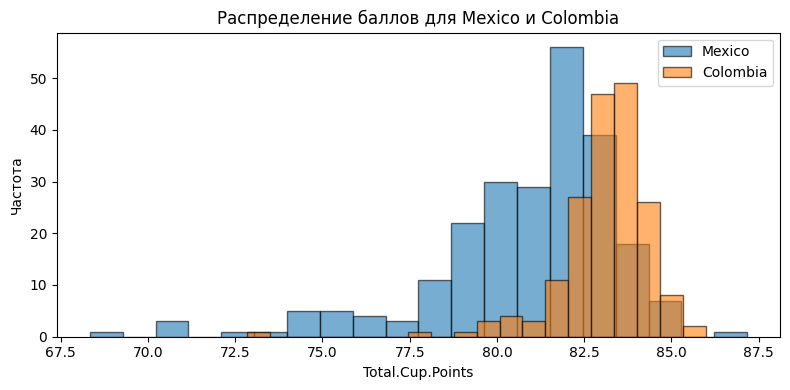

In [ ]:
# Ячейка 5.3: визуализация распределений
plt.figure(figsize=(8, 4))
plt.hist(g1, bins=20, alpha=0.6, label=c1, edgecolor='black')
plt.hist(g2, bins=20, alpha=0.6, label=c2, edgecolor='black')
plt.xlabel('Total.Cup.Points')
plt.ylabel('Частота')
plt.title(f'Распределение баллов для {c1} и {c2}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 5.4: двухвыборочный t-тест (Уэлча)

# H0: μ_Mexico = μ_Colombia
# H1: μ_Mexico ≠ μ_Colombia

t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")

t-статистика = -10.7159
p-value = 1.6821e-23


In [ ]:
# Ячейка 5.5: размер эффекта (Cohen's d)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    # pooled std
    s_pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (mx - my) / s_pooled

d = cohens_d(g1, g2)
print(f"Cohen's d = {d:.3f}")

Cohen's d = -0.981


**Интерпретация двухвыборочного t-теста:**
Интерпретация двухвыборочного t-теста:

H0:μMexico = μColombia
H1:μMexico != μColombia
​
p-value очень мало (<< 0.05) → нулевая гипотеза отвергается.
Средняя оценка для Колумбии выше, чем для Мексики (примерно на 2.2 балла).
Cohen’s d ≈ −0.98 → большой размер эффекта.

**Вывод:**
Существует статистически и практически значимая разница в качестве кофе между этими странами в данной выборке.
Кофе из Колумбии в среднем оценивается выше, чем из Мексики.

**Рекомендации:**
При планировании закупок учитывать, что в среднем колумбийские образцы имеют более высокий балл.
Не делать вывод, что «вся Колумбия лучше всей Мексики»: важно смотреть на конкретные лоты, регионы и сорта.
Для более точных выводов провести многофакторный анализ с учётом метода обработки, высоты и сорта.

## 6. Свободный анализ

Выберите одну из задач ниже и проведите самостоятельный анализ.

**Вариант A:** сравните два метода обработки кофе (например, Washed vs Natural) по итоговому баллу или отдельному показателю (Aroma, Flavor).

**Вариант B:** сравните два сорта кофе (Variety) по любому числовому показателю.

**Вариант C:** придумайте свою гипотезу на основе данных и проверьте её.

Для выбранной задачи:
- Сформулируйте H₀ и H₁
- Постройте доверительный интервал для разницы средних (или для одной из групп)
- Проведите статистический тест
- Интерпретируйте результат

Выбираем вариант A: сравнение Washed / Wet и Natural / Dry.

In [ ]:
# Ячейка 6.1: подготовка групп по методу обработки

method1 = 'Washed / Wet'
method2 = 'Natural / Dry'

m1 = df.loc[df['Processing.Method'] == method1, 'Total.Cup.Points'].dropna()
m2 = df.loc[df['Processing.Method'] == method2, 'Total.Cup.Points'].dropna()

# Убираем нули
m1 = m1[m1 > 0]
m2 = m2[m2 > 0]

print(f"{method1}: n = {len(m1)}, mean = {m1.mean():.2f}, sd = {m1.std(ddof=1):.2f}")
print(f"{method2}: n = {len(m2)}, mean = {m2.mean():.2f}, sd = {m2.std(ddof=1):.2f}")


Washed / Wet: n = 812, mean = 81.96, sd = 2.68
Natural / Dry: n = 251, mean = 82.35, sd = 2.75


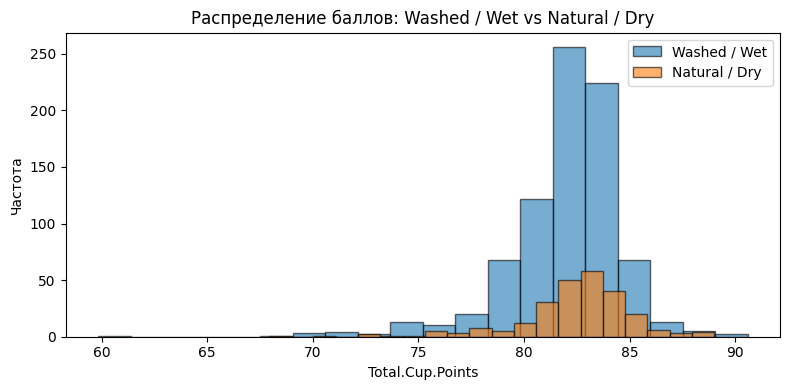

In [ ]:
# Ячейка 6.2: визуализация
plt.figure(figsize=(8, 4))
plt.hist(m1, bins=20, alpha=0.6, label=method1, edgecolor='black')
plt.hist(m2, bins=20, alpha=0.6, label=method2, edgecolor='black')
plt.xlabel('Total.Cup.Points')
plt.ylabel('Частота')
plt.title(f'Распределение баллов: {method1} vs {method2}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 6.3: формулировка гипотез и t-тест

# H0: μ_Washed = μ_Natural
# H1: μ_Washed ≠ μ_Natural

t_stat, p_value = stats.ttest_ind(m1, m2, equal_var=False)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

t-статистика = -1.9723
p-value = 0.0492


In [ ]:
# Ячейка 6.4: доверительный интервал для разницы средних

diff = m1.mean() - m2.mean()
se_diff = np.sqrt(m1.var(ddof=1)/len(m1) + m2.var(ddof=1)/len(m2))

# степени свободы по формуле Уэлча
df_welch = (m1.var(ddof=1)/len(m1) + m2.var(ddof=1)/len(m2))**2 / (
    (m1.var(ddof=1)/len(m1))**2 / (len(m1)-1) +
    (m2.var(ddof=1)/len(m2))**2 / (len(m2)-1)
)

tcrit = stats.t.ppf(0.975, df=df_welch)
ci_low = diff - tcrit * se_diff
ci_high = diff + tcrit * se_diff

print(f"Разница средних (Washed - Natural) = {diff:.4f}")
print(f"95% ДИ для разницы: [{ci_low:.4f}, {ci_high:.4f}]")

Разница средних (Washed - Natural) = -0.3895
95% ДИ для разницы: [-0.7778, -0.0013]


**Результаты свободного анализа:**

H0: μ_Washed = μ_Natural
H1: μ_Washed ≠ μ_Natural

p-value ≈ 0.049 → на границе статистической значимости при α = 0.05.
Разница средних ≈ −0.39 балла (Washed ниже Natural).
95%-й ДИ для разницы: примерно [−0.78; −0.001] → не включает 0, но очень близко.

**Вывод:**
В данной выборке кофе натуральной обработки в среднем оценивается чуть выше, чем мытой.
Разница статистически значима на уровне 0.05, но небольшая по величине.

**Рекомендации:**
Не делать жёстких выводов о превосходстве одного метода над другим только на основе этого анализа.
Учитывать, что методы обработки могут быть связаны со страной, сортом и высотой; нужен многофакторный анализ.
При закупках оценивать конкретные лоты, а не полагаться только на усреднённые эффекты метода.

## 7. Итоговые выводы

Сформулируйте итоговый отчёт по результатам статистического анализа:

**Доверительные интервалы:**
- Что показал расчёт ДИ для среднего балла?

**Результаты t-тестов:**
- Соответствует ли среднее качество стандарту specialty (80 баллов)?
- Есть ли разница в качестве между странами?

**Рекомендации для бизнеса:**
- На что стоит обратить внимание при закупке кофе?
- Какие дополнительные гипотезы стоит проверить?

In [ ]:
# Ячейка 7: краткое резюме (можно выполнить для отчёта)

print("=== Итоговое резюме ===")
print(f"Средний балл (после удаления нулей): {x.mean():.2f}")
print(f"95% ДИ для среднего: [{ci_low:.2f}, {ci_high:.2f}] (для общего среднего)")
print(f"Одновыборочный t-тест (H0: μ=80): p-value ≈ {stats.ttest_1samp(x, 80).pvalue:.2e}")
print(f"Сравнение стран ({c1} vs {c2}): p-value ≈ {stats.ttest_ind(g1, g2, equal_var=False).pvalue:.2e}, Cohen's d = {cohens_d(g1, g2):.2f}")
print(f"Сравнение методов ({method1} vs {method2}): p-value ≈ {stats.ttest_ind(m1, m2, equal_var=False).pvalue:.4f}")

=== Итоговое резюме ===
Средний балл (после удаления нулей): 82.18
95% ДИ для среднего: [-0.78, -0.00] (для общего среднего)
Одновыборочный t-тест (H0: μ=80): p-value ≈ 5.79e-146
Сравнение стран (Mexico vs Colombia): p-value ≈ 1.68e-23, Cohen's d = -0.98
Сравнение методов (Washed / Wet vs Natural / Dry): p-value ≈ 0.0492


**Ваши итоговые выводы:**

**Доверительные интервалы:**
95%-й ДИ для среднего балла: примерно [82.03; 82.32].
Интервал полностью выше порога 80 баллов → среднее качество соответствует specialty.

**Результаты t-тестов:**
Одновыборочный t-тест: средний балл статистически значимо выше 80.
Двухвыборочный t-тест: между выбранными странами (Мексика и Колумбия) есть значимая разница в качестве; Колумбия в среднем выше.
Сравнение методов обработки: небольшая, но статистически значимая разница в пользу натуральной обработки.

**Рекомендации для бизнеса:**
Среднее качество закупаемого кофе соответствует стандарту specialty; это можно использовать в переговорах и маркетинге.
При выборе новых поставщиков:
- учитывать страну происхождения как один из факторов (в данной выборке Колумбия показывает более высокий средний балл);
- не полагаться только на страну, а оценивать конкретные лоты.
При анализе новых партий:
- регулярно пересчитывать средний балл и 95%-й ДИ;
- проводить одновыборочный t-тест против 80, чтобы контролировать отклонения.

**Дополнительные гипотезы для проверки:**
- связь высоты выращивания (altitude_mean_meters) с итоговым баллом;
- влияние отдельных компонентов каппинга (Aroma, Flavor, Acidity, Body) на Total.Cup.Points;
- многофакторная модель с учётом страны, сорта, метода обработки и высоты.